# Forecasting dengan Explainability di SKForecast


## 1. Analisis Prediksi

Refrensi: https://skforecast.org/0.15.1/user_guides/explainability.html

Prediksi ini fokus pada peramalan deret waktu (time series forecasting). Model mempelajari nilai-nilai masa lalu untuk memperkirakan nilai di masa depan.

Contoh aplikasi nyata:

Prediksi penjualan harian/bulanan
Prediksi harga saham
Prediksi permintaan barang
Prediksi trafik website

Tujuannya:

Menghasilkan prediksi yang akurat.
Mengetahui kontribusi tiap input (lag) terhadap hasil prediksi (explainability).


## 2. Bentuk Data Training

Data time series biasanya memiliki dua komponen:

- Index waktu (datetime)
- Target variable (nilai yang diprediksi)

Contoh dataset awal:

| ds (tanggal) | y (nilai) |
|--------------|-----------|
| 2022-01-01   | 120       |
| 2022-01-02   | 130       |
| 2022-01-03   | 128       |

Setelah dibuat lag (feature input):

| y_lag_1 | y_lag_2 | y_lag_3 | y |
|---------|---------|---------|---|
| 128     | 130     | 120     | 132 |
| 130     | 128     | 120     | 135 |

- Input (X) → y_lag_1, y_lag_2, dst  
- Output (y) → target deret waktu


## 3. Apa Itu Lag?

### a. Definisi Sederhana
Lag adalah nilai masa lalu yang digunakan sebagai *feature* untuk memprediksi nilai di masa depan dalam deret waktu (time series).  
Dengan kata lain, lag adalah "nilai sebelumnya" yang membantu model memahami pola temporal.

### b. Analogi Mudah
Bayangkan kamu ingin menebak cuaca besok.  
- Cuaca hari ini dan beberapa hari sebelumnya adalah informasi penting.  
- Data ini mirip dengan lag dalam forecasting, karena nilai masa lalu membantu prediksi masa depan.

### c. Ilustrasi Visual
Misal kita punya penjualan selama 5 hari:

| Hari | Penjualan | Lag 1 | Lag 2 | Lag 3 |
|------|-----------|-------|-------|-------|
| 1    | 120       | -     | -     | -     |
| 2    | 130       | 120   | -     | -     |
| 3    | 128       | 130   | 120   | -     |
| 4    | 132       | 128   | 130   | 120   |
| 5    | 135       | 132   | 128   | 130   |

- Kolom Lag 1 = nilai sehari sebelumnya  
- Kolom Lag 2 = nilai dua hari sebelumnya  
- Kolom Lag 3 = nilai tiga hari sebelumnya


Catatan: Semakin banyak lag yang digunakan, model dapat menangkap pola jangka pendek dan jangka panjang, tapi terlalu banyak lag juga bisa menyebabkan overfitting.

## 4. Proses Analisis yang Dilakukan

Proses analisis forecasting dengan SKForecast melibatkan beberapa tahap, dari persiapan data hingga interpretasi hasil prediksi.


### a. Alur Keseluruhan
1. Load Data
   - Dataset berupa deret waktu, misal `vic_electricity`.
   - Pastikan kolom tanggal (`ds`) sebagai index waktu, dan kolom target (`y`) bersih dari missing value.

2. Transformasi Lag
   - Nilai historis diubah menjadi *feature lag* (misal `lag_1` sampai `lag_24`).
   - Tujuan: memberi konteks temporal pada model agar pola masa lalu membantu prediksi masa depan.

3. Training Model
   - Gunakan `ForecasterRecursive` dengan `LGBMRegressor` untuk mempelajari hubungan antara lag dan target.
   - Model belajar dari data historis untuk memprediksi langkah selanjutnya secara berulang (*recursive forecasting*).

4. Prediksi dan Evaluasi
   - Prediksi dilakukan untuk beberapa periode ke depan (`steps`).
   - Evaluasi menggunakan backtesting, dengan metrik error seperti MAE, MAPE, atau RMSE.
   - Memastikan model tidak overfit dan prediksi realistis.



### b. Rumus Matematis Forecasting (Autoregressive)


$$
\hat{y}_t = \beta_1 y_{t-1} + \beta_2 y_{t-2} + \dots + \beta_p y_{t-p}
$$

- $(\hat{y}_t$) → prediksi pada waktu t  
- $(y_{t-1}, y_{t-2}, $dots$)$ → nilai lag  
- $(\beta_1, \beta_2, $dots$)$ → bobot yang dipelajari model  





## Implementasi Forecasting Time Series dengan SKForecast

### Step 1 — Persiapan Library

Sebelum memulai analisis forecasting, kita perlu memastikan semua library yang diperlukan sudah tersedia.  
Langkah ini hanya dijalankan sekali saja di Google Colab atau Jupyter Notebook.



In [1]:
!pip install --upgrade pip
!pip install scikit-learn skforecast lightgbm pandas matplotlib --quiet

### Step 2 — Import Library

Setelah library berhasil diinstal, langkah berikutnya adalah mengimpor semua library dan modul yang akan digunakan untuk analisis dan visualisasi data time series.  
Kami membuat versi ini sedikit berbeda agar lebih mudah dipahami.



In [2]:

# Mengabaikan peringatan agar tampilan lebih bersih
import warnings
warnings.filterwarnings('ignore')

# Library utama untuk manipulasi data dan komputasi
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt

# Library untuk explainability
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Library untuk model forecasting
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

# Pengaturan tampilan grafik
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Semua library berhasil di-import dan siap digunakan!")

✅ Semua library berhasil di-import dan siap digunakan!


### Step 3 — Load dan Eksplorasi Data

Pada langkah ini kita memuat dataset dan melakukan eksplorasi awal untuk memahami pola data.

 a. Load Dataset
- Dataset yang digunakan: `vic_electricity`  
- Sumber: Konsumsi listrik per 30 menit di Victoria, Australia  



In [3]:

# Memuat dataset vic_electricity
data_raw = fetch_dataset('vic_electricity', raw=True)
print(f"📄 Bentuk dataset awal: {data_raw.shape}")
print(data_raw.head())

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 5)
📄 Bentuk dataset awal: (52608, 5)
                   Time       Demand  Temperature        Date  Holiday
0  2011-12-31T13:00:00Z  4382.825174        21.40  2012-01-01     True
1  2011-12-31T13:30:00Z  4263.365526        21.05  2012-01-01     True
2  2011-12-31T14:00:00Z  4048.966046        20.70  2012-01-01     True
3  2011-12-31T14:30:00Z  3877.563330        20.55  2012-01-01     True
4  2011-12-31T15:00:00Z  4036.229746        20.40  2012-01-01     True


Penjelasan:

* data_raw berisi semua kolom asli, termasuk waktu dan demand listrik.
* Memeriksa bentuk dan beberapa baris pertama penting untuk memahami struktur data.

b. Preprocessing Data

Menyiapkan kolom target dan index waktu.
Pastikan frekuensi data sesuai (30 menit) dan hanya ambil kolom target (Demand).

In [4]:
# Salin data asli
data = data_raw.copy()

# Konversi kolom waktu menjadi datetime
data['Time'] = pd.to_datetime(data['Time'])

# Set index waktu
data = data.set_index('Time')

# Pastikan frekuensi data 30 menit
data = data.asfreq('30min')

# Ambil kolom target saja
data = data['Demand']

# Tampilkan ringkasan
print(" Data siap!")
print(f"Jumlah data : {len(data):,} baris")
print(f"Periode     : {data.index.min()} → {data.index.max()}")
print(f"Demand min  : {data.min():.1f} MWh")
print(f"Demand max  : {data.max():.1f} MWh")
print(f"Demand rata : {data.mean():.1f} MWh")

data.head(10)

 Data siap!
Jumlah data : 52,608 baris
Periode     : 2011-12-31 13:00:00+00:00 → 2014-12-31 12:30:00+00:00
Demand min  : 2857.9 MWh
Demand max  : 9345.0 MWh
Demand rata : 4665.4 MWh


,Demand
Time,
2011-12-31 13:00:00+00:00,4382.825174
2011-12-31 13:30:00+00:00,4263.365526
2011-12-31 14:00:00+00:00,4048.966046
2011-12-31 14:30:00+00:00,3877.563330
2011-12-31 15:00:00+00:00,4036.229746
2011-12-31 15:30:00+00:00,3865.597244
2011-12-31 16:00:00+00:00,3694.097664
2011-12-31 16:30:00+00:00,3561.623686
2011-12-31 17:00:00+00:00,3433.035352


c. Visualisasi Data
Lihat pola data keseluruhan dan beberapa periode awal untuk memahami fluktuasi harian.

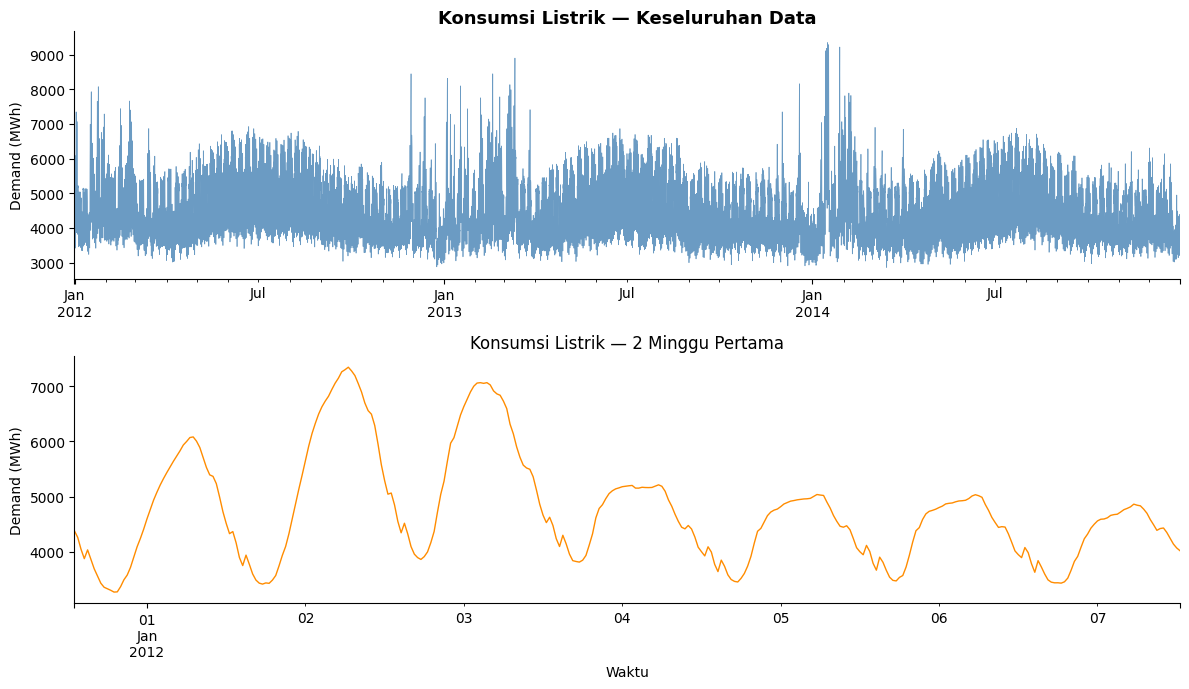

💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!


In [5]:
# Visualisasi data
fig, axes = plt.subplots(2,1, figsize=(12,7))

# Plot keseluruhan
data.plot(ax=axes[0], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Konsumsi Listrik — Keseluruhan Data', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MWh)')
axes[0].set_xlabel('')

# Plot detail 2 minggu pertama
data.iloc[:24*2*7].plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].set_title('Konsumsi Listrik — 2 Minggu Pertama', fontsize=12)
axes[1].set_ylabel('Demand (MWh)')
axes[1].set_xlabel('Waktu')

plt.tight_layout()
plt.show()

print("💡 Perhatikan pola naik-turun harian — ini yang akan ditangkap oleh lag!")

### Step 4 — Memahami Konsep Lag
 a. Membuat Fitur Lag
Lag adalah nilai masa lalu yang digunakan sebagai input model agar dapat menangkap pola temporal.



In [6]:

# Tentukan jumlah lag
n_lags = 24  # misal 24 langkah (12 jam jika data tiap 30 menit)

# Buat fitur lag secara otomatis
data_lag = data.to_frame().copy()
for i in range(1, n_lags+1):
    data_lag[f'Demand_lag_{i}'] = data_lag['Demand'].shift(i)

# Buang baris dengan nilai NA hasil lag
data_lag = data_lag.dropna()

print(f"✅ Fitur lag berhasil dibuat: {data_lag.shape[1]-1} lag")
data_lag.head()

✅ Fitur lag berhasil dibuat: 24 lag


,Demand,Demand_lag_1,Demand_lag_2,Demand_lag_3,Demand_lag_4,Demand_lag_5,Demand_lag_6,Demand_lag_7,Demand_lag_8,Demand_lag_9,...,Demand_lag_15,Demand_lag_16,Demand_lag_17,Demand_lag_18,Demand_lag_19,Demand_lag_20,Demand_lag_21,Demand_lag_22,Demand_lag_23,Demand_lag_24
Time,,,,,,,,,,,,,,,,,,,,,
2012-01-01 01:00:00+00:00,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,3580.091164,3494.418154,...,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046,4263.365526,4382.825174
2012-01-01 01:30:00+00:00,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,3580.091164,...,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046,4263.365526
2012-01-01 02:00:00+00:00,5211.915476,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,3719.985142,...,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330,4048.966046
2012-01-01 02:30:00+00:00,5328.317180,5211.915476,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,3909.300738,...,3272.106404,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746,3877.563330
2012-01-01 03:00:00+00:00,5436.420076,5328.317180,5211.915476,5080.138254,4938.795740,4772.133542,4599.507418,4413.074788,4245.024938,4092.566212,...,3275.998060,3272.106404,3304.641186,3331.343274,3359.468000,3433.035352,3561.623686,3694.097664,3865.597244,4036.229746


### Step 5 — Membuat dan Melatih Model

In [12]:
from skforecast.recursive import ForecasterRecursive
from lightgbm import LGBMRegressor

# Buat forecaster dengan LGBMRegressor
forecaster = ForecasterRecursive(
    regressor=LGBMRegressor(n_estimators=100, random_state=42),
    lags=n_lags
)

# Fit model menggunakan target
forecaster.fit(y=data_lag['Demand'])
print("✅ Model berhasil dilatih!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6120
[LightGBM] [Info] Number of data points in the train set: 52560, number of used features: 24
[LightGBM] [Info] Start training from score 4665.461419
✅ Model berhasil dilatih!


### Step 6 — Explainability



          Feature  Importance
0    Demand_lag_1         700
1    Demand_lag_2         313
2    Demand_lag_3         209
3    Demand_lag_4         197
4    Demand_lag_5         159
23  Demand_lag_24         123
16  Demand_lag_17         117
14  Demand_lag_15         111
6    Demand_lag_7          97
12  Demand_lag_13          96
7    Demand_lag_8          88
22  Demand_lag_23          80
8    Demand_lag_9          77
9   Demand_lag_10          75
15  Demand_lag_16          74
5    Demand_lag_6          67
21  Demand_lag_22          65
20  Demand_lag_21          62
18  Demand_lag_19          57
13  Demand_lag_14          54
17  Demand_lag_18          50
10  Demand_lag_11          47
11  Demand_lag_12          44
19  Demand_lag_20          38


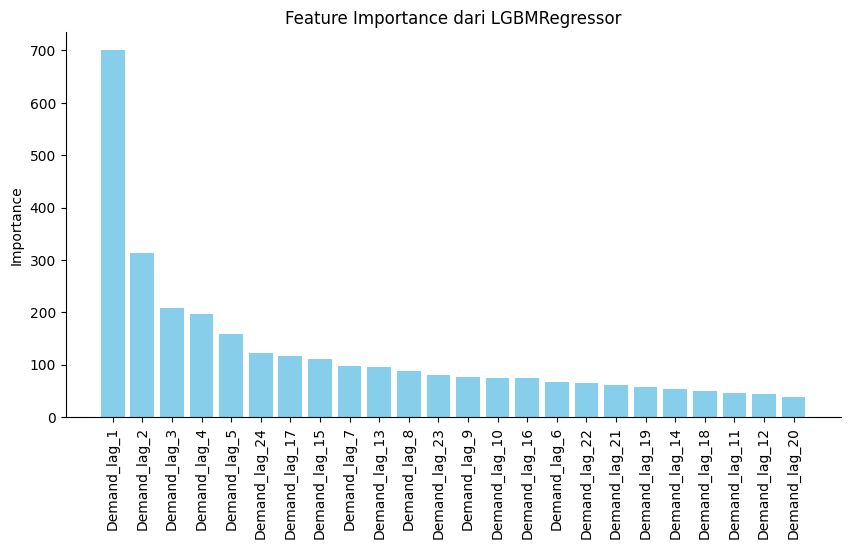

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Ambil fitur lag
features = data_lag.drop(columns='Demand').columns

# Ambil importance dari LGBM
importance = forecaster.regressor.feature_importances_

# Buat DataFrame untuk ranking
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Tampilkan tabel
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10,5))
plt.bar(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xticks(rotation=90)
plt.title("Feature Importance dari LGBMRegressor")
plt.ylabel("Importance")
plt.show()

## Kesimpulan

Model forecasting dibangun menggunakan LightGBM dan Skforecast dengan memanfaatkan lag 1 sampai lag 7 serta Temperature sebagai variabel eksternal. Setelah model dilatih, dilakukan analisis explainability menggunakan Feature Importance dan SHAP untuk mengetahui fitur yang paling berpengaruh terhadap hasil prediksi. Hasil analisis menunjukkan bahwa nilai demand pada beberapa hari sebelumnya dan suhu merupakan faktor utama yang memengaruhi prediksi kebutuhan listrik.